
# Lab1_4: PDE_capacitor

In [8]:
#Librery
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt

In [5]:
#up files from Drive
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
#Read
path = 'drive/MyDrive/Colab Notebooks/Fisica_Computacional_1/figures/'
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'
filename5 = 'Laplace_df_capacitor.png'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Potential and Electric field from a capacitor

#### Lab1_4_PDE_capacitor:

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:

\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{outside}
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

* Compute numerically (use finite difference method) the electric field.

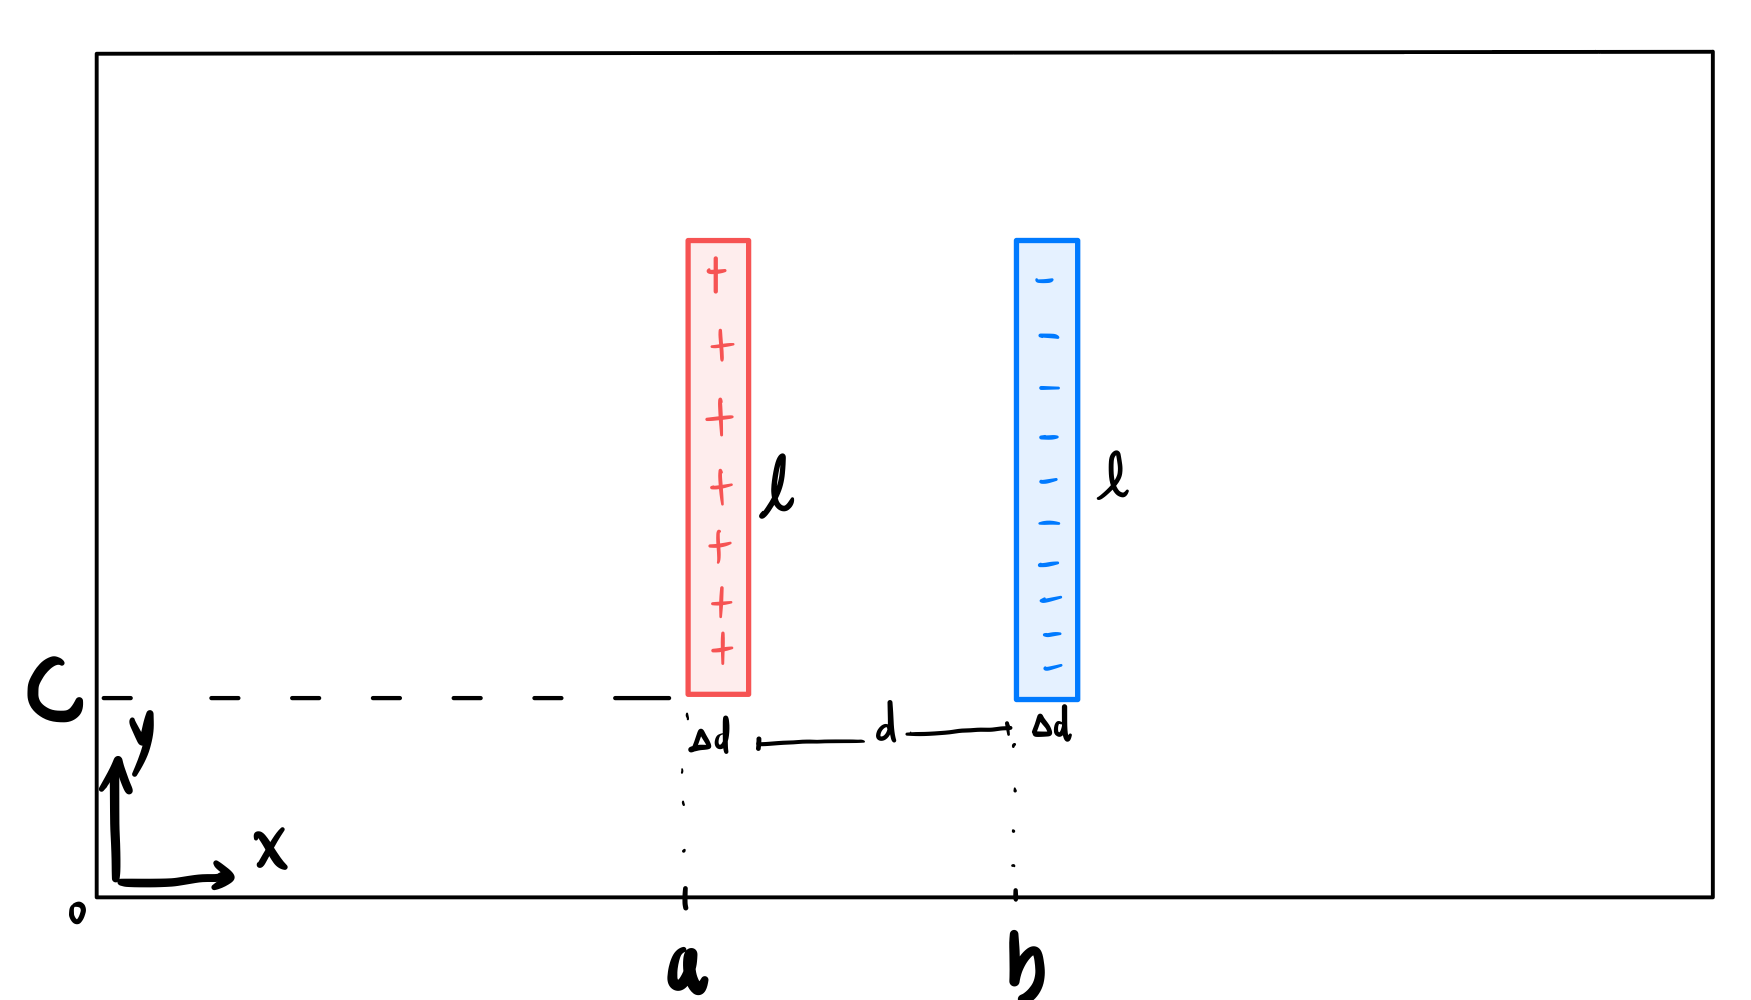

In [6]:
from IPython.display import Image
Image(filename=path+filename5, width=500)

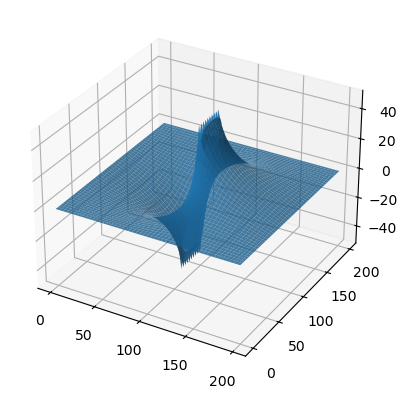

In [69]:
import numpy as np
import matplotlib.pyplot as plt

err = 1e-5
d = 10
l = 20

volt = 50

Nx = 200
Ny = 200

d_grid = d*Nx/100
l_grid = l*Ny/100


U = np.zeros((Nx, Ny))
Uaux = np.zeros((Nx,Ny))

U[int((Nx + d_grid)/2), int((Ny - l_grid)/2):int((Ny + l_grid)/2)] = volt
U[int((Nx - d_grid)/2), int((Ny - l_grid)/2):int((Ny + l_grid)/2)] = -volt

niter = 0
while True:
    niter += 1
    Uaux = U.copy()
    U[1:-1, 1:-1] = 0.25 * (
        Uaux[0:-2, 1:-1] + Uaux[2:, 1:-1] +
        Uaux[1:-1, 0:-2] + Uaux[1:-1, 2:]
    )
    U[int((Nx + d_grid)/2), int((Ny - l_grid)/2):int((Ny + l_grid)/2)] = volt
    U[int((Nx - d_grid)/2), int((Ny - l_grid)/2):int((Ny + l_grid)/2)] = -volt

    loop_err = np.max(np.abs(U-Uaux))
    if loop_err < err:
        break

X, Y = np.meshgrid(
    np.arange(Nx),
    np.arange(Ny)
)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, U[X,Y], alpha=0.8)

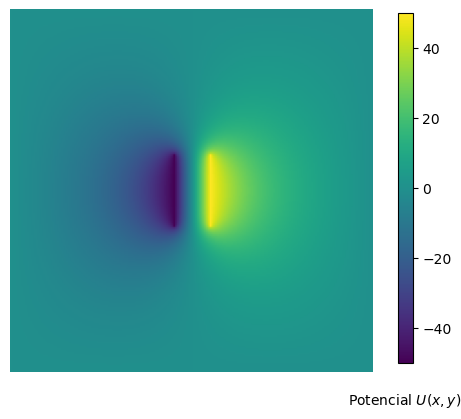

In [70]:
fig, ax = plt.subplots(figsize=(5,5) )
im = ax.imshow(U.T.copy())
ax.set_axis_off()

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("Potencial $U(x,y)$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

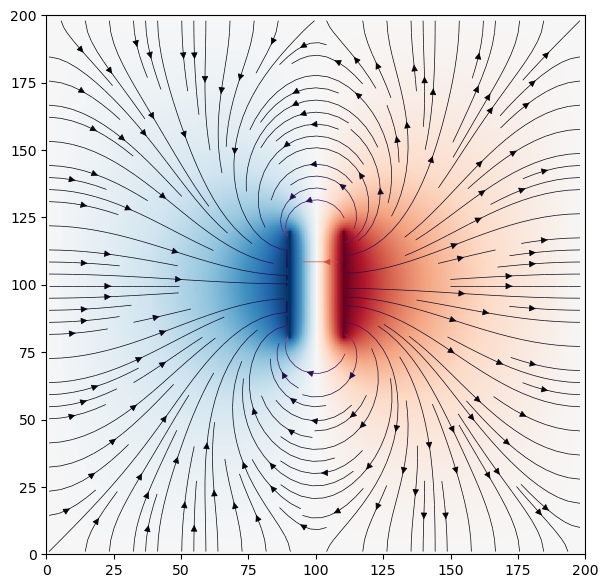

In [71]:
E = -np.stack([
    (U[2:, 1:-1] - U[0:-2, 1:-1]) / 2,
    (U[1:-1, 2:] - U[1:-1, 0:-2]) / 2,
], axis=-1)

Ex = E[..., 0]
Ey = E[..., 1]

# Interior grid coordinates matching E's shape (Nx-2, Ny-2)
x = np.arange(1, Nx-1)
y = np.arange(1, Ny-1)
X, Y = np.meshgrid(x, y, indexing='ij')

fig, ax = plt.subplots(figsize=(7, 7))

# Background: potential
ax.imshow(U.T, origin='lower', cmap='RdBu_r', extent=[0, Nx, 0, Ny])

# Streamlines, colored by field magnitude
magnitude = np.sqrt(Ex**2 + Ey**2)
ax.streamplot(X.T, Y.T, Ex.T, Ey.T,
                color = magnitude.T, cmap = 'inferno',
                density=1.5, linewidth=0.5)

ax.set_aspect('equal')
plt.show()

streamplot(): Creates streamlines to show the "flow" of the field, which is often cleaner for dense data.

Excelente. Muy bien... 
Nota 5.0